# HistGradientBoosting Classifier - PS-S06E09: Electric Vehicle Purchases

This notebook trains a **HistGradientBoosting Classifier** model (Scikit-Learn) for Kaggle Playground Series Season 6 Episode 9, predicting the binary target `Will_Buy_EV` (`Yes` / `No`).

Key features:
* **Shared Utilities**: Leverages `ExperimentSetup`, `FeatureFactory`, and `ModelVisualizer`.
* **SQLite-Backed Optuna Persistence**: Hyperparameters tuned via Optuna with persistent SQLite storage (`histgb_study.db`).
* **Fold Cache Pattern**: Features engineered once per fold and cached for fast Optuna evaluation.
* **Multi-Seed Ensembling**: Models evaluated across 5 stratified folds and multiple random seeds.
* **Prediction Export**: Probabilities saved to `predictions/histgb_oof_probs.csv` and `predictions/histgb_test_probs.csv` for downstream model ensembling and blending.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import optuna

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_feature_engineering import FeatureFactory
from ps_s06e09_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='HistGB',
    use_gpu=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'ev_ratios',
    'charging_accessibility',
    'financial_incentives',
    'range_anxiety_interactions',
    'buyer_readiness_score',
    'income_age_benchmarks',
    'missing_flags',
    'group_aggregations',
]

ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].map({'Yes': 1, 'No': 0})

X_test = ff.transform(test_df)

cat_cols = ['Gender', 'City_Type', 'Current_Car_Type']
for c in cat_cols:
    if c in X.columns:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[c] = encoder.fit_transform(X[[c]])
        X_test[c] = encoder.transform(X_test[[c]])

ordinal_map = {
    'Range_Anxiety_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Home_Charging_Possible': {'No': 0, 'Yes': 1},
    'Subsidy_Available': {'No': 0, 'Yes': 1}
}
for col, mapping in ordinal_map.items():
    if col in X.columns:
        X[col] = X[col].astype(str).map(mapping).fillna(0).astype(float)
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(0).astype(float)

cat_mask = [col in cat_cols for col in X.columns]

print(f'Engineered Train shape: {X.shape}')
print(f'Engineered Test shape:  {X_test.shape}')

  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding financial incentive features...
  -> Adding range anxiety interaction features...
  -> Adding buyer readiness score features...
  -> Adding income and age benchmark features...
  -> Adding group aggregation features...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding fin

## 4. Hyperparameter Tuning (Optuna + SQLite Storage)

In [5]:
optuna_filename = 'optuna_params_histgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print('Starting Optuna hyperparameter optimization for HistGradientBoosting...')

    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((
            X.iloc[tr_idx].copy(),
            X.iloc[val_idx].copy(),
            y.iloc[tr_idx].copy(),
            y.iloc[val_idx].copy()
        ))

    def objective(trial):
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 31, 127),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 20, 150),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 20.0, log=True),
            'max_bins': trial.suggest_int('max_bins', 128, 255),
            'max_iter': 600,
            'early_stopping': True,
            'n_iter_no_change': 30,
            'random_state': seed,
            'categorical_features': cat_mask
        }

        scores = []
        for X_tr, X_val, y_tr, y_val in fold_cache:
            clf = HistGradientBoostingClassifier(**params)
            clf.fit(X_tr, y_tr)
            val_preds = clf.predict_proba(X_val)[:, 1]
            scores.append(roc_auc_score(y_val, val_preds))

        return np.mean(scores)

    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(
        study_name='histgb_tuning_v1',
        storage='sqlite:///histgb_study.db',
        load_if_exists=True,
        direction='maximize',
        sampler=sampler
    )

    if best_params is not None:
        best_params = {
            "learning_rate": 0.04104638879162461,
            "max_leaf_nodes": 37,
            "min_samples_leaf": 75,
            "l2_regularization": 13.138087446295886,
            "max_bins": 212
        }
    study.enqueue_trial(best_params)

    study.optimize(
        objective,
        n_trials=30,
        timeout=7200,
        show_progress_bar=True
    )

    print(f'Best Trial ROC AUC: {study.best_value:.6f}')
    best_params = study.best_params

    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)

print('Final Hyperparameters:')
print(json.dumps(best_params, indent=2))

Loaded 5 parameters from optuna_params_histgb.json
Final Hyperparameters:
{
  "learning_rate": 0.04104638879162461,
  "max_leaf_nodes": 37,
  "min_samples_leaf": 75,
  "l2_regularization": 13.138087446295886,
  "max_bins": 212
}


In [6]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

Optuna wasn't run


## 5. Model Training & Prediction Export

In [7]:
seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))

models = []
eval_results = []
seed_scores = {}

base_params = {
    'max_iter': 800,
    'early_stopping': True,
    'n_iter_no_change': 40,
    'categorical_features': cat_mask,
    **best_params
}

for current_seed in seeds:
    print(f'\n--- Training HistGradientBoosting across 5 Folds with Seed {current_seed} ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    seed_oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = HistGradientBoostingClassifier(**base_params, random_state=current_seed)
        model.fit(X_tr, y_tr)

        val_pred_prob = model.predict_proba(X_val)
        seed_oof[val_idx] = val_pred_prob[:, 1]

        oof_probs[val_idx, 0] += val_pred_prob[:, 0] / len(seeds)
        oof_probs[val_idx, 1] += val_pred_prob[:, 1] / len(seeds)

        test_pred_prob = model.predict_proba(X_test)
        test_probs[:, 0] += test_pred_prob[:, 0] / (len(seeds) * 5)
        test_probs[:, 1] += test_pred_prob[:, 1] / (len(seeds) * 5)

        models.append(model)
        fold_auc = roc_auc_score(y_val, val_pred_prob[:, 1])
        print(f'Seed {current_seed} | Fold {fold+1} ROC AUC: {fold_auc:.6f}')

    seed_auc = roc_auc_score(y, seed_oof)
    seed_scores[current_seed] = seed_auc
    print(f'>>> Seed {current_seed} OOF ROC AUC: {seed_auc:.6f}')

print('\n==========================================')
for s, score in seed_scores.items():
    print(f'Seed {s:<5} OOF ROC AUC: {score:.6f}')
overall_auc = roc_auc_score(y, oof_probs[:, 1])
print('------------------------------------------')
print(f'Overall Multi-Seed OOF ROC AUC: {overall_auc:.6f}')
print('==========================================')


--- Training HistGradientBoosting across 5 Folds with Seed 10301 ---
Seed 10301 | Fold 1 ROC AUC: 0.940564
Seed 10301 | Fold 2 ROC AUC: 0.942176
Seed 10301 | Fold 3 ROC AUC: 0.942210
Seed 10301 | Fold 4 ROC AUC: 0.941165
Seed 10301 | Fold 5 ROC AUC: 0.942833
>>> Seed 10301 OOF ROC AUC: 0.941774

--- Training HistGradientBoosting across 5 Folds with Seed 42 ---
Seed 42 | Fold 1 ROC AUC: 0.940489
Seed 42 | Fold 2 ROC AUC: 0.941663
Seed 42 | Fold 3 ROC AUC: 0.942731
Seed 42 | Fold 4 ROC AUC: 0.942311
Seed 42 | Fold 5 ROC AUC: 0.941586
>>> Seed 42 OOF ROC AUC: 0.941743

--- Training HistGradientBoosting across 5 Folds with Seed 2026 ---
Seed 2026 | Fold 1 ROC AUC: 0.941399
Seed 2026 | Fold 2 ROC AUC: 0.940838
Seed 2026 | Fold 3 ROC AUC: 0.943061
Seed 2026 | Fold 4 ROC AUC: 0.941626
Seed 2026 | Fold 5 ROC AUC: 0.941760
>>> Seed 2026 OOF ROC AUC: 0.941727

--- Training HistGradientBoosting across 5 Folds with Seed 777 ---
Seed 777 | Fold 1 ROC AUC: 0.942359
Seed 777 | Fold 2 ROC AUC: 0.9418

In [8]:
os.makedirs('predictions', exist_ok=True)

oof_df_out = pd.DataFrame({
    'id': train_ids,
    'prob_0': oof_probs[:, 0],
    'prob_1': oof_probs[:, 1]
})
oof_df_out.to_csv('predictions/histgb_oof_probs.csv', index=False)

test_df_out = pd.DataFrame({
    'id': test_ids,
    'prob_0': test_probs[:, 0],
    'prob_1': test_probs[:, 1]
})
test_df_out.to_csv('predictions/histgb_test_probs.csv', index=False)

print('Exported:')
print(f"  - OOF: predictions/histgb_oof_probs.csv ({oof_df_out.shape})")
print(f"  - Test: predictions/histgb_test_probs.csv ({test_df_out.shape})")

Exported:
  - OOF: predictions/histgb_oof_probs.csv ((668665, 3))
  - Test: predictions/histgb_test_probs.csv ((286571, 3))


## 6. Performance Visualization

<Figure size 800x600 with 0 Axes>

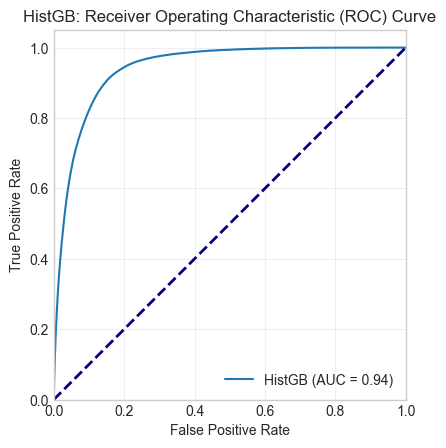

Confusion matrix, without normalization


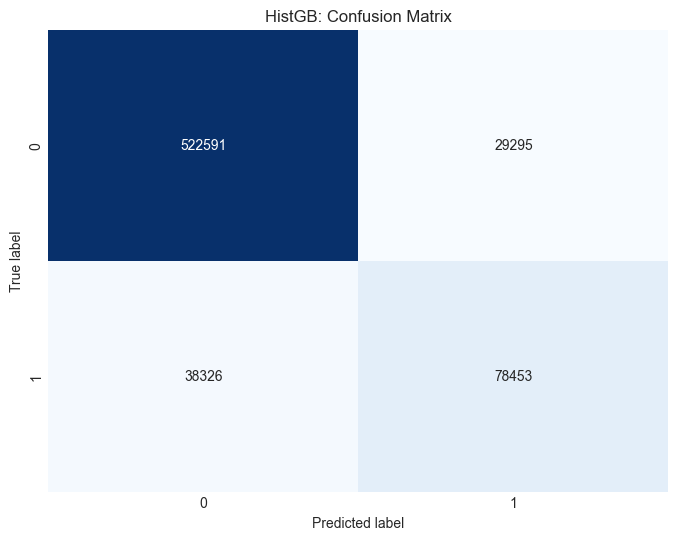

In [9]:
viz = ModelVisualizer(model_name='HistGB')
viz.plot_roc_curve(y, oof_probs[:, 1])
viz.plot_confusion_matrix(y, (oof_probs[:, 1] > 0.5).astype(int))